## 3장 2강: 로지스틱 회귀와 교차 검증

#### 로지스틱 회귀 Logistic Regression : 회귀 방식을 이용한 분류 모델

ex)
- 특성: 꽃잎 너비, 꽃잎 높이
- 정답: setosa, versicolor ...


[Actication Function]
- z -> 활성화 함수 통과 -> 최종 분류 확률 (0~1)
- 즉 로지스틱 회귀란 **분류** 형태의 모델. 분류하기 위해선 활성화 함수가 필요함
- z: logits
- 0 ~ 1 값으로 logits 값을 변환, logits(z)는 선형회귀로 얻어낸 값임 
- linear regression: z= wx+b 
- 활성화 함수로 얻어낸 값 
  - 양성 클래스: 1
  - 음성 클래스: 0
- 왜 쓰냐? 선형회귀 결과인 z값만으로는 어떤 문제의 **확률**을 대답할 수 없음 (ex. 이 꽃이 세토사 품종일 확률은 몇%인가?)
- activation function을 쓰면 z값을 0과 1, 즉 0% ~ 100%인 확률 값으로 설명해줌.
- 기준 정하기(hyperparameter): 0.5를 기준(바뀔 수 있음)으로 양성클래스/음성클래스 정하기

---

### 로지스틱 회귀 - 이진분류 Binary Classification
- class가 2개 - 1(양성 클래스)과 0(음성 클래스)
- 1. 활성화 함수: **Sigmoid** 함수 (z값을 0~1로 압축), z값이 커질수록 1에 수렴, z값이 큰 음수일수록 0에 수렴. 기준 정하기 by 개발자 : 
- 2. 손실함수(Loss Function)
  - **BCE** (Binary Cross Entropy) : 이진분류에서 사용
    - equation: 


[binary 모델 흐름]
1. input
2. logistics regression
3. activation function BCE
4. output

---

### 로지스틱 회귀 - 다중분류 Multiclass Classification

- soft max activation function 사용
- 활성화 함수: **Soft-Max**
- 손실 함수
  - **CCE** (Categorical Cross Entropy)
    - One-Hot Encoding 필수
    - equation: 

  - **SCCE** (Sparse Categorical Cross Entropy)
    - 정수로 받고 (0, 1, 2, 3, ...) 내부적으로 해당 인덱스 확률 계산
    - equation:
    - One-Hot Encoding 대신 사용
    - y(최종 타깃 데이터, 즉 정답 데이터)를 정수형태로 유지하고 내부적으로 계산 -> 메모리 효율성 뛰어남
  
  -  **Embedding Layer**
     -  데이터가 수만 개를 넘어설 때 사용 유리
     -  0으로 채워진 불필요한 공간을 버림(희소 벡터)
     -  실수 형태의 연속 벡터 공간으로 압축하여 맵핑


[multiple 모델 흐름]
1. input
2. logistics regression
3. activation function CCE
4. output

---

#### One-Hot Encoding
- 1, 2, 3 X
- [1, 0, 0], [0, 1, 0], [0, 0, 1] O
- 단점: 데이터가 많아 분류가 많아질 경우 메모리 소모가 큼


---

### K-Fold Cross Validation

- ex) 훈련세트를 5개의 fold로 나누고, 각 fold값의 평균을 내서 검증 점수를 내보냄
- k-fold 하기 전 shuffle 필수

---

### 1. 로지스틱 회귀: 선형 회귀로 분류를 해결하는 마법
#### 1.5 범주형 데이터 전처리: 원핫 인코딩의 명과 암

원핫 인코딩 실습

실습에 필요한 도구 불러오기

In [17]:
from sklearn.preprocessing import OneHotEncoder # one-hot encoding tool

간단한 가상의 과일 범주 데이터를 준비합니다.

In [18]:
data = pd.DataFrame({'과일': ['사과', '바나나', '딸기', '바나나']}) # 클래스는 총 3개
data

,과일
0,사과
1,바나나
2,딸기
3,바나나


원핫 인코딩 변환

In [19]:
encoder = OneHotEncoder(sparse_output=False) # sparse categorical cross entropy : 정수로 받고 내부적으로 해당 인덱스 확률을 계산해 줌 (one-hot encoding과 비교)
encoded_data = encoder.fit_transform(data[['과일']]) # 대괄호 2개로 2차원 변환해야함. 
encoded_data


array([[0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.]])

변환 결과를 보기 좋게 판다스 데이터프레임으로 만들어 출력합니다.

### 3. 붓꽃 데이터(Iris) 이진 및 다중 분류 실습
#### 3.1 데이터 불러오기 및 학습 준비

실습에 필요한 도구 불러오기

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss

붓꽃 데이터셋(Iris.csv) 불러오기

In [21]:
df = pd.read_csv("Iris.csv")
df.head() # feature 단위가 같으므로 scaling 진행 x

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [22]:
df['Species'].unique() # 중복제외한 유의미한 column값 보기

<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

실습 1. 이진 분류용 데이터 구성

In [23]:
# species 값을 이진분류
# sectosa와 versicolor만 

df_binary = df[df['Species'].isin(['Iris-setosa', 'Iris-versicolor'])].copy() #isin()으로 column에서 해당 값만 뽑아내기, copy()해서 원본이 바뀌지 않도록 새로운 셋을 하나 만들기.

# 특성에 대한 데이터 뽑기 -peatal len, petal wid
# 시각화를 직관적으로 만들기 위해 꽃잎 길이(PetalLengthCm)와 꽃잎 너비(PetalWidthCm) 두 피처만 꺼냅니다.
X_binary = df_binary[['PetalLengthCm', 'PetalWidthCm']]

# 품종 이름을 컴퓨터가 분류 계산을 할 수 있도록 숫자(Setosa=0, Versicolor=1)로 이진분류합니다.
y_binary = df_binary['Species'].map({'Iris-setosa': 0, 'Iris-versicolor': 1}) 

# 이진 분류용 데이터를 훈련 80% / 테스트 20% 비율로 분리합니다.
X_bin_train, X_bin_test, y_bin_train, y_bin_test = train_test_split(
    X_binary, y_binary, test_size=0.2, random_state=42, stratify=y_binary # stratify를 통해 분류시 데이터가 50:50 비율로 나눠지게 됨(y_binary 데이터 2개, 각 데이터 1:1로 쪼갬)
)

X_binary.head()

,PetalLengthCm,PetalWidthCm
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


In [24]:
# 이진 분류 모델 학습
binary_model = LogisticRegression()
binary_model.fit(X_bin_train, y_bin_train) # .fit(feature, label) binary model 학습

bin_test_preds = binary_model.predict(X_bin_test) # logistic regression, z값 구하기

print(bin_test_preds)
print(y_bin_test.values) #1차원 값으로 이진환된 테스트값 보여주기
bin_accuracy = accuracy_score(y_bin_test, bin_test_preds)
print(f"이진 분류 테스트 정확도: {bin_accuracy:.4f}")

[1 1 1 1 0 0 0 1 0 0 0 1 0 0 0 1 1 0 1 1]
[1 1 1 1 0 0 0 1 0 0 0 1 0 0 0 1 1 0 1 1]
이진 분류 테스트 정확도: 1.0000


실습 2. 다중 분류용 데이터 구성

In [25]:
df['Species'].unique() # column values check...

<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

In [26]:
X_multi = df[['PetalLengthCm', 'PetalWidthCm']]
y_multi = df['Species'].map({'Iris-setosa': 0, 'Iris-versicolor':1, 'Iris-virginica': 2}) # one-hot encoding

print("X_multi:", X_multi.head())
print("y_multi:", y_multi.head())

X_multi:    PetalLengthCm  PetalWidthCm
0            1.4           0.2
1            1.4           0.2
2            1.3           0.2
3            1.5           0.2
4            1.4           0.2
y_multi: 0    0
1    0
2    0
3    0
4    0
Name: Species, dtype: int64


#### 3.2 모델 학습 및 결정 경계(Decision Boundary) 시각화
모델 학습 및 교차 검증하기

In [27]:
# 다중분류 훈련세트, 테스트 세트 80-20 분류
X_multi_train, X_multi_test, y_multi_train, y_multi_test = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42 ,stratify=y_multi # y_multi 레이블 값 기준으로 비율 맞추기
)

In [28]:
# 다중분류 모델 학습
multi_model = LogisticRegression()
multi_model.fit(X_multi_train, y_multi_train)

# K-Fold 교차검증
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(multi_model, X_multi_train, y_multi_train, cv=kf)
print("cv_scores:", cv_scores)
print("교차 검증 정확도 평균: %.4f" % cv_scores.mean())

# 예측
multi_test_preds = multi_model.predict(X_multi_test)
print("예측한 값:", multi_test_preds)
print("원래  값:", y_multi_test.values) #numpy values안넣으면 너무 길어짐

# 정확도 측정
multi_accuracy = accuracy_score(y_multi_test, multi_test_preds) # (e = y - y hat)
print(f"정확도: {multi_accuracy:.4f}")

# Loss 측정
multi_test_probs = multi_model.predict_proba(X_multi_test)
multi_loss = log_loss(y_multi_test, multi_test_probs)
print(f"Loss: {multi_loss:.4f}")

cv_scores: [0.91666667 0.95833333 0.95833333 1.         0.95833333]
교차 검증 정확도 평균: 0.9583
예측한 값: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]
원래  값: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]
정확도: 0.9667
Loss: 0.1705


두 가지 실습 결과를 한눈에 비교하기 위한 Matplotlib 시각화

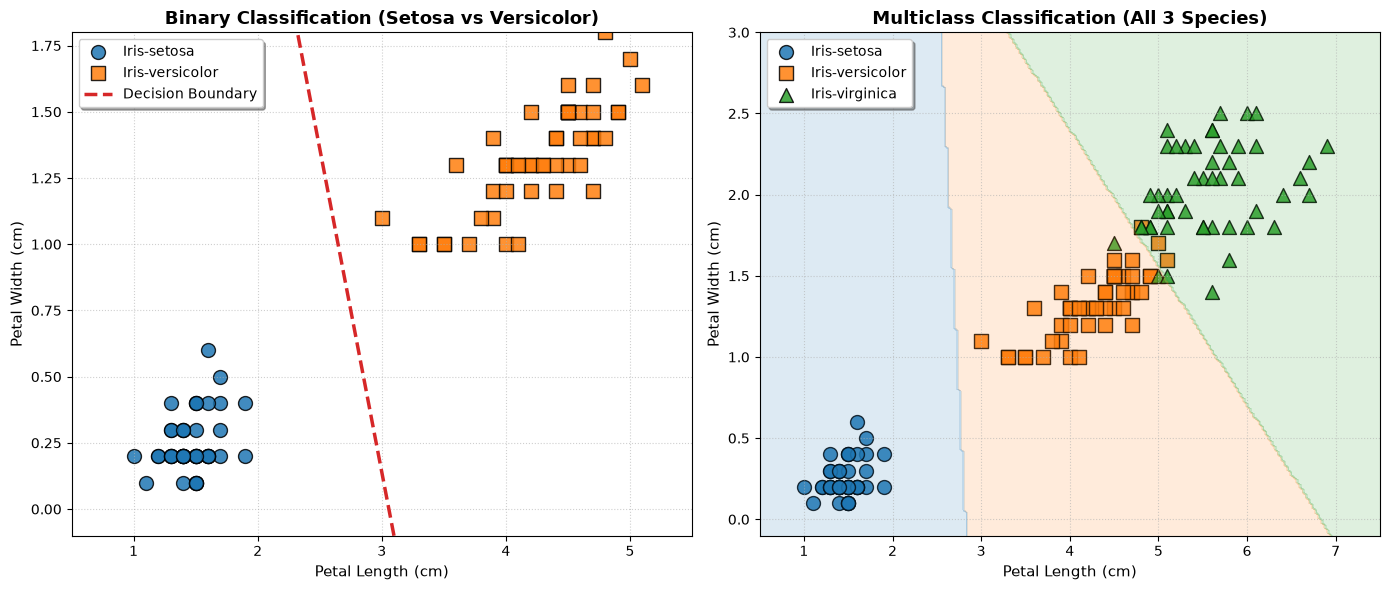

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# [왼쪽 플롯] 이진 분류 선형 결정 경계선 그리기
ax1 = axes[0]  
colors_binary = ['#1F77B4', '#FF7F0E']  
markers_binary = ['o', 's']
species_binary = ['Iris-setosa', 'Iris-versicolor']

for species, color, marker in zip(species_binary, colors_binary, markers_binary):
    subset = df_binary[df_binary['Species'] == species]
    ax1.scatter(subset['PetalLengthCm'], subset['PetalWidthCm'], label=species, color=color, marker=marker, s=100, edgecolor='black', alpha=0.85)

# 선형 분류 경계면 공식 유도: w1*x1 + w2*x2 + b = 0 => x2 = -(w1*x1 + b)/w2
w1, w2 = binary_model.coef_[0][0], binary_model.coef_[0][1]
b = binary_model.intercept_[0]

x_vals = np.linspace(0.8, 5.2, 100)
y_vals = -(w1 * x_vals + b) / w2
ax1.plot(x_vals, y_vals, '--', color='#D62728', linewidth=2.5, label='Decision Boundary')

ax1.set_title("Binary Classification (Setosa vs Versicolor)", fontsize=13, fontweight='bold')
ax1.set_xlabel("Petal Length (cm)", fontsize=11)
ax1.set_ylabel("Petal Width (cm)", fontsize=11)
ax1.set_xlim(0.5, 5.5)
ax1.set_ylim(-0.1, 1.8)
ax1.legend(loc='upper left', frameon=True, shadow=True)
ax1.grid(True, linestyle=':', alpha=0.6)


# [오른쪽 플롯] 다중 분류 영역 맵 시각화
ax2 = axes[1]
colors_multi = {'Iris-setosa': '#1F77B4', 'Iris-versicolor': '#FF7F0E', 'Iris-virginica': '#2CA02C'}
markers_multi = {'Iris-setosa': 'o', 'Iris-versicolor': 's', 'Iris-virginica': '^'}

for species in ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']:
    subset = df[df['Species'] == species]
    ax2.scatter(subset['PetalLengthCm'], subset['PetalWidthCm'], label=species, color=colors_multi[species], marker=markers_multi[species], s=100, edgecolor='black', alpha=0.85)

# 가로축과 세로축 격자를 촘촘히 쪼개 전 구역에 소프트맥스 예측 결과 칠하기
xx, yy = np.meshgrid(np.linspace(0.5, 7.5, 200), np.linspace(-0.1, 3.0, 200))
grid_points = np.c_[xx.ravel(), yy.ravel()]


grid_df = pd.DataFrame(grid_points, columns=['PetalLengthCm', 'PetalWidthCm'])
Z_pred = multi_model.predict(grid_df)

# 교안 수정
Z_num = Z_pred.reshape(xx.shape)

# 결정 구역에 예쁜 투명도를 주어 영역 채우기
custom_cmap = ListedColormap(['#1F77B4', '#FF7F0E', '#2CA02C'])
ax2.contourf(xx, yy, Z_num, alpha=0.15, cmap=custom_cmap)

ax2.set_title("Multiclass Classification (All 3 Species)", fontsize=13, fontweight='bold')
ax2.set_xlabel("Petal Length (cm)", fontsize=11)
ax2.set_ylabel("Petal Width (cm)", fontsize=11)
ax2.set_xlim(0.5, 7.5)
ax2.set_ylim(-0.1, 3.0)
ax2.legend(loc='upper left', frameon=True, shadow=True)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()